[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/liamdev07/machine-learning-laboratory/blob/main/10_Perceptron_Algorithm/practical_10.ipynb)

# Practical 10 — Perceptron Learning Algorithm

## 1. Aim & Objectives

**Aim:** To implement the Perceptron learning algorithm and evaluate its performance on a real dataset.

**Objectives:**
1. Train a Perceptron on the Sonar dataset (mines vs rocks) after scaling the features.
2. Record the accuracy after every epoch to observe how learning progresses.
3. Report the final accuracy with a confusion matrix and plot the learning curve.

## 2. Complete Python Code


Shape of dataset : (208, 61)
label
M    111
R     97
Name: count, dtype: int64

Weights learned (first 5) : [ 0.2346  0.1039 -0.1041  0.2635 -0.2361]
Bias learned              : 0.13

Final training accuracy : 0.8759
Final test accuracy     : 0.7937

Classification report:
              precision    recall  f1-score   support

        Rock       0.77      0.79      0.78        29
        Mine       0.82      0.79      0.81        34

    accuracy                           0.79        63
   macro avg       0.79      0.79      0.79        63
weighted avg       0.79      0.79      0.79        63



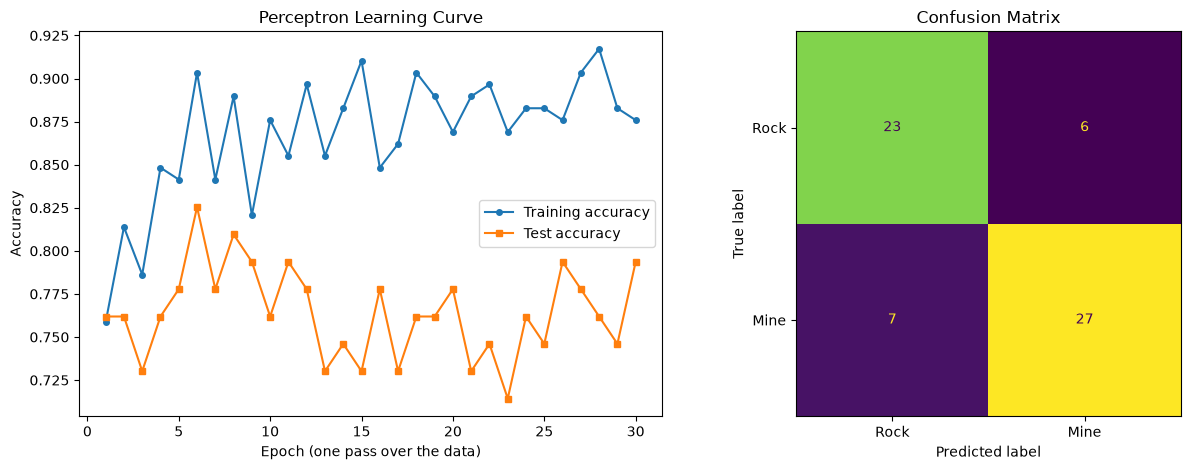

In [ ]:
# Practical 10 - Perceptron Learning Algorithm
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
CSV = "data/sonar.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/10_Perceptron_Algorithm/data/sonar.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path)

print("Shape of dataset :", df.shape)
print(df["label"].value_counts())

# Step 2: Features and target (M = mine -> 1, R = rock -> 0)
X = df.drop(columns="label")
y = (df["label"] == "M").astype(int)

# Step 3: Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Train the Perceptron one epoch at a time
model = Perceptron(eta0=0.01, random_state=42)
train_acc, test_acc = [], []

for epoch in range(1, 31):
    model.partial_fit(X_train, y_train, classes=np.array([0, 1]))
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

print("\nWeights learned (first 5) :", np.round(model.coef_[0][:5], 4))
print("Bias learned              :", np.round(model.intercept_[0], 4))

# Step 5: Final performance
y_pred = model.predict(X_test)
print("\nFinal training accuracy :", round(train_acc[-1], 4))
print("Final test accuracy     :", round(test_acc[-1], 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Rock", "Mine"]))

# Step 6: Plot the learning curve and the confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(range(1, 31), train_acc, marker="o", markersize=4, label="Training accuracy")
ax[0].plot(range(1, 31), test_acc, marker="s", markersize=4, label="Test accuracy")
ax[0].set_title("Perceptron Learning Curve")
ax[0].set_xlabel("Epoch (one pass over the data)")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, display_labels=["Rock", "Mine"], ax=ax[1], colorbar=False
)
ax[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()


## 3. Line-by-Line Code Explanation

- `from sklearn.linear_model import Perceptron` — the simplest neural unit. It computes `w·x + b` and predicts class 1 if the answer is positive, otherwise class 0.
- `X = df.drop(columns="label")` — the 60 sonar energy readings of each object.
- `(df["label"] == "M").astype(int)` — converts the letters into numbers: M (mine) becomes 1 and R (rock) becomes 0, because the model needs numeric labels.
- `train_test_split(..., stratify=y)` — 70% for training and 30% for testing, keeping the mine/rock balance in both.
- `scaler.fit_transform(X_train)` / `scaler.transform(X_test)` — scale using only the training statistics, so the test set stays unseen.
- `Perceptron(eta0=0.01)` — `eta0` is the learning rate, i.e. how big a correction is applied to the weights after every mistake.
- `model.partial_fit(X_train, y_train, classes=np.array([0, 1]))` — trains for exactly **one** epoch (one pass over the data). Calling it inside a loop lets us watch the learning happen. The `classes` argument is needed the first time so the model knows both labels exist.
- The `for epoch in range(1, 31)` loop — repeats that single-epoch training 30 times and stores the training and test accuracy each time.
- Perceptron update rule: whenever a sample is misclassified, the weights move as `w = w + eta * (y_true - y_pred) * x`. Correctly classified samples cause no change.
- `model.coef_[0]` — the learned weight for every feature; `model.intercept_[0]` — the learned bias.
- `accuracy_score(...)` — fraction of correct predictions, stored once per epoch.
- `classification_report(..., target_names=["Rock", "Mine"])` — precision, recall and F1 printed with readable class names.
- `ax[0].plot(...)` twice — draws two curves, training and test accuracy, against the epoch number.
- `ConfusionMatrixDisplay.from_estimator(...)` — the final confusion matrix with Rock/Mine labels.
- `plt.show()` — displays both graphs.


## 4. Output & Graph Interpretation

The learning curve rises quickly in the first few epochs and then keeps oscillating between roughly 0.85 and 0.91, because the Perceptron changes its weights after every misclassified sample and the Sonar data is not perfectly linearly separable.

The training accuracy stays above the test accuracy and the confusion matrix shows a few mines predicted as rocks, which is the expected limit of a single linear neuron.
